# Título

# Análise e Validação do Modelo PINN 

Este notebook tem como objetivo carregar o modelo PINN de Black-Scholes previamente treinado e avaliá-lo em um novo conjunto de dados (PETR4 2024) que não foi visto durante o treinamento (out-of-sample).

**Objetivos:**
1.  **Validar a Acurácia:** Verificar o desempenho de precificação do modelo em dados novos.
2.  **Analisar a Volatilidade:** Extrair a superfície de volatilidade implícita e o *smile* para o novo ativo.
3.  **Verificar as Gregas:** Analisar o comportamento do Delta (∂V/∂S) aprendido.
4.  **Gerar Insights:** Produzir gráficos e métricas de alta qualidade para inclusão em um artigo acadêmico.

## 1. Configuration for Evaluation

### a. Import and Paths 

In [1]:
# Imports and paths
import os
import json
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 3D plotting
from mpl_toolkits.mplot3d import Axes3D  

# tqdm (opcional para loops longos)
from tqdm import tqdm

# Scipy for implied vol solver
from scipy.optimize import brentq

# Torch and project imports
import torch
from torch.utils.data import TensorDataset, DataLoader

# Para importa a classe/modelo e funções de processamento
from src.model import PINN_BlackScholes
from src.config import MODEL_CONFIG, PATHS, DATA_CONFIG, TRAINING_CONFIG
from src.data_loader import carregar_e_processar_dados_opcoes, carregar_taxa_juros

# Carregar Paths 
ROOT = os.getcwd()  # ou caminho do projeto
PATH_RESULTS = os.path.join(ROOT, 'resultados')
PATH_MODEL = os.path.join(PATH_RESULTS, 'modelo_final')
TRAIN_HISTORY_PATH = os.path.join(PATH_RESULTS, 'training_history.csv')
MODEL_WEIGHTS_PATH = os.path.join(PATH_MODEL, 'best_model_weights.pth')
DATA_STATS_PATH = os.path.join(PATH_MODEL, 'data_stats.json')

# Carregar Dados brutos
RAW_DATA_DIR = os.path.join(ROOT, 'dados', 'brutos')
RAW_2024_DIR = os.path.join(RAW_DATA_DIR, 'Databricks')  

# Carregar data_stats 
with open(DATA_STATS_PATH, 'r') as f:
    data_stats = json.load(f)
data_stats

# Instancia modelo
# Ajusta config para consistência (mantém problem_type do config original)
model_config = MODEL_CONFIG.copy()
# Garantir input_size correto (já definido no config)
device = torch.device(TRAINING_CONFIG['device'] if 'device' in TRAINING_CONFIG else 'cpu')
model = PINN_BlackScholes(config=model_config, data_stats=data_stats)
model.to(device)

# Carrega pesos
state = torch.load(MODEL_WEIGHTS_PATH, map_location=device)
model.load_state_dict(state)
model.eval()
print("Ok!")



Ok!


### b. Helpers: Black-Scholes price & implied vol solver

In [2]:
# Helpers BS price and implied vol (European call)
# Small, robust implementations for Black-Scholes European call price and implied vol

from math import log, sqrt, exp
from scipy.stats import norm

def bs_call_price(S, K, T, r, sigma):
    """
    Black-Scholes European call price (scalar or numpy arrays).
    Assumes T is time-to-maturity in years (T>0). If T==0 returns intrinsic value.
    """
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    r = np.asarray(r, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    price = np.zeros_like(S, dtype=float)
    # handle T==0 (payoff)
    mask_T0 = (T <= 0)
    price[mask_T0] = np.maximum(S[mask_T0] - K[mask_T0], 0.0)
    mask = ~mask_T0
    if mask.any():
        St = S[mask]; Kt = K[mask]; Tt = T[mask]; rt = r[mask]; sig = sigma[mask]
        d1 = (np.log(St/Kt) + (rt + 0.5*sig*sig)*Tt) / (sig*np.sqrt(Tt))
        d2 = d1 - sig*np.sqrt(Tt)
        price[mask] = St*norm.cdf(d1) - Kt*np.exp(-rt*Tt)*norm.cdf(d2)
    return price

def implied_volatility_call(market_price, S, K, T, r, sigma_bounds=(1e-6, 3.0)):
    """
    Solve implied volatility via brentq on difference BS_price - market_price.
    Returns NaN if solver fails.
    """
    market_price = float(market_price)
    if market_price <= max(0.0, S - K*np.exp(-r*T)):
        # price below intrinsic lower bound -> implied vol ~ 0
        return 0.0
    def price_diff(sig):
        return float(bs_call_price(np.array([S]), np.array([K]), np.array([T]), np.array([r]), np.array([sig]))[0]) - market_price
    a, b = sigma_bounds
    try:
        root = brentq(price_diff, a, b, maxiter=200, xtol=1e-6)
        return float(root)
    except Exception:
        return float('nan')
    
print("Ok!")


Ok!


### c. Processar e Preparar Dados de 2021-2023 (Treinamento) e 2024 (Validação)

In [3]:
# Carrega e processa dados usando seu data_loader (mantendo preprocess original)
# Função wrapper que produz X (normalized) e y (premium), e DataFrame original com colunas úteis
def prepare_dataset_from_folder(folder_path, df_juros=None, max_samples=None):
    """
    Procura arquivos CSV na pasta, concatena, processa e retorna X, y, df_proc.
    Usa carregar_e_processar_dados_opcoes do projeto (espera dados no formato do repositório).
    """
    # Reutiliza função do projeto que provavelmente exige um arquivo consolidado.
    # Se sua função precisa de caminho específico, ajuste conforme necessário.
    # Aqui assumimos que carregar_e_processar_dados_opcoes aceita (raw_data_path, df_juros)
    df = carregar_e_processar_dados_opcoes(folder_path, df_juros)
    if df is None or df.empty:
        raise RuntimeError(f"Nenhum dado processado em {folder_path}")
    if max_samples is not None and len(df) > max_samples:
        df = df.sample(n=max_samples, random_state=42)
    # Normalização usando data_stats (mesmas transformações do treino)
    S_min, S_max = data_stats['S_min'], data_stats['S_max']
    K_min, K_max = data_stats['K_min'], data_stats['K_max']
    T_max = data_stats['T_max']
    df['S_norm'] = (df['spot_price'] - S_min) / (S_max - S_min)
    df['K_norm'] = (df['strike'] - K_min) / (K_max - K_min)
    df['T_norm'] = df['time_to_maturity'] / T_max
    # Colunas de entrada esperadas: ['S_norm','K_norm','T_norm','r','premium']
    X = df[['S_norm','K_norm','T_norm','r','premium']].values.astype(float)
    y = df[['premium']].values.astype(float)
    return X, y, df

# Carregar taxas de juros (se necessário) — sua função já implementa carregar_taxa_juros
df_juros = carregar_taxa_juros(PATHS['selic_data'])
# Preparar dataset de treino (2021-2023)
X_train, y_train, df_train = prepare_dataset_from_folder(RAW_DATA_DIR, df_juros)
print("Train:", len(df_train), "amostras")
# Preparar dataset 2024 (validacao)
X_val, y_val, df_val = prepare_dataset_from_folder(RAW_2024_DIR, df_juros)
print("Val 2024:", len(df_val), "amostras")


Carregando dados da taxa de juros de: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\dados\brutos\taxa_selic.csv
Dados da taxa de juros carregados com sucesso.
Encontrados 25 arquivos de ativos para processar...


Processando arquivos de ativos: 100%|██████████| 25/25 [00:21<00:00,  1.15it/s]


Unificando todos os dataframes de ativos...
Realizando engenharia de features...
Processamento concluído. DataFrame final com 894278 amostras.
Train: 894278 amostras
Encontrados 8 arquivos de ativos para processar...


Processando arquivos de ativos: 100%|██████████| 8/8 [00:08<00:00,  1.05s/it]


Unificando todos os dataframes de ativos...
Realizando engenharia de features...
Processamento concluído. DataFrame final com 405015 amostras.
Val 2024: 405015 amostras


## 2. Evaluation of Training History

Evolução das perdas durante o treinamento

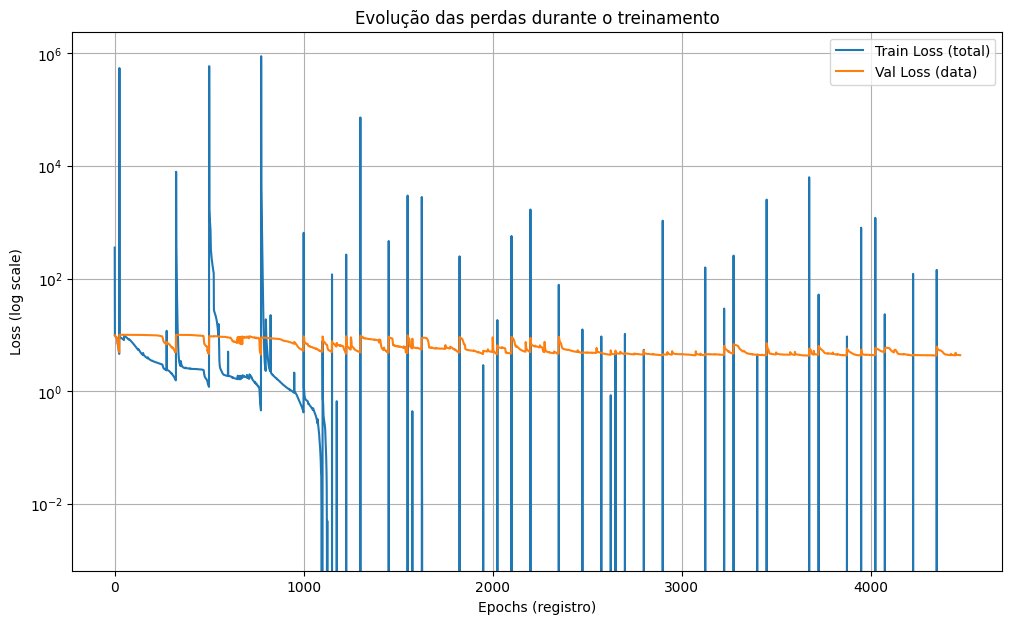

In [4]:
# Cell 3 - Carrega histórico de treino e plota curvas simples
history = pd.read_csv(TRAIN_HISTORY_PATH)
history.head()

# Plots das losses
plt.figure(figsize=(12, 7))
plt.plot(history['train_loss'], label='Train Loss (total)')
plt.plot(history['val_loss'], label='Val Loss (data)')
plt.yscale('log')
plt.xlabel('Epochs (registro)')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.title('Evolução das perdas durante o treinamento')
plt.grid(True)
plt.show()




Evolução dos pesos (data vs PDE) ( Escala Ajustada com log )

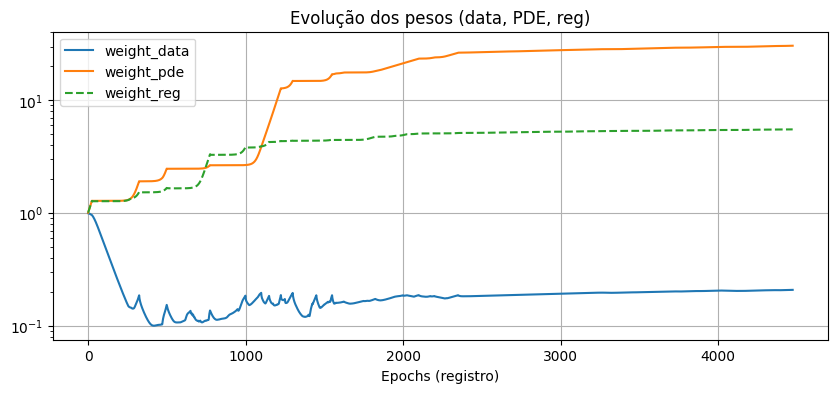

In [21]:
# Plot dos pesos 
if 'weight_data' in history.columns and 'weight_pde' in history.columns and 'weight_reg' in history.columns:
    plt.figure(figsize=(10,4))
    plt.plot(history['weight_data'], label='weight_data')
    plt.plot(history['weight_pde'], label='weight_pde')
    # Adiciona o plot do weight_reg, com um estilo de linha diferente
    plt.plot(history['weight_reg'], label='weight_reg', linestyle='--') 
    
    plt.yscale('log')
    plt.xlabel('Epochs (registro)')
    plt.legend()
    
    # --- Título atualizado ---
    plt.title('Evolução dos pesos (data, PDE, reg)') 
    
    plt.grid(True)
    plt.show()

Evolução dos pesos (data vs PDE) ( Subplot dos pesos )

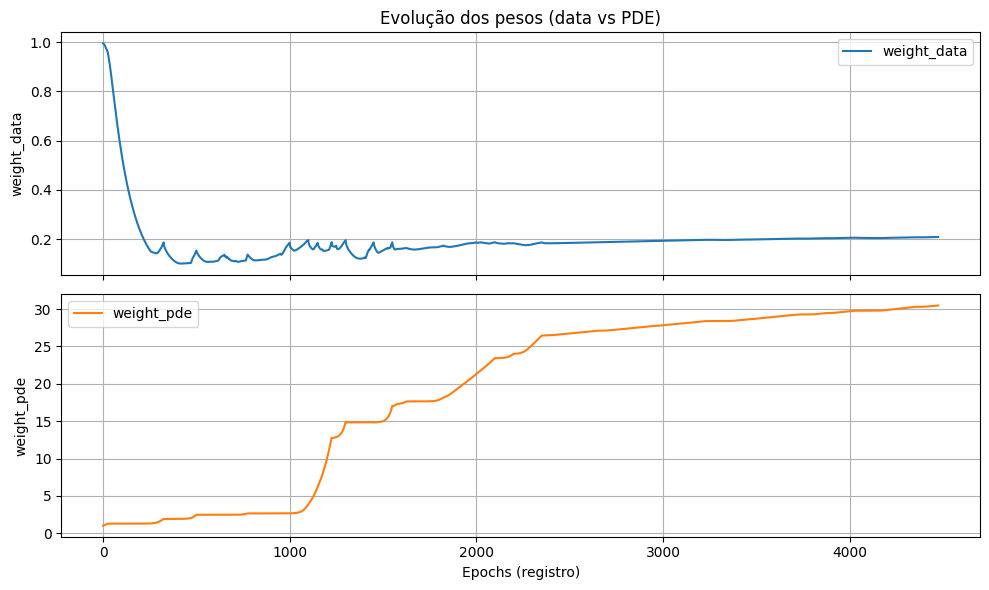

In [6]:
# Plot dos pesos com subplots
if 'weight_data' in history.columns and 'weight_pde' in history.columns:
    # 1. Criar a figura com 2 linhas, 1 coluna, compartilhando o eixo X
    fig, (ax1, ax2) = plt.subplots(
        nrows=2, 
        ncols=1, 
        figsize=(10, 6), # Um pouco mais alto para caber os dois plots
        sharex=True       # Eixo X compartilhado
    )

    # 2. Plotar 'weight_data' no gráfico de cima (ax1)
    ax1.plot(history['weight_data'], label='weight_data', color='tab:blue')
    ax1.set_ylabel('weight_data')
    ax1.legend()
    ax1.grid(True)
    ax1.set_title('Evolução dos pesos (data vs PDE)') # Título no plot superior

    # 3. Plotar 'weight_pde' no gráfico de baixo (ax2)
    ax2.plot(history['weight_pde'], label='weight_pde', color='tab:orange')
    ax2.set_ylabel('weight_pde')
    ax2.set_xlabel('Epochs (registro)') # Rótulo do X só no plot inferior
    ax2.legend()
    ax2.grid(True)

    # 4. Mostrar o gráfico
    plt.tight_layout() # Ajusta o espaçamento
    plt.show()

Inferência (preço e sigma) 

In [7]:
# Inferência em lote (usa DataLoader para evitar estourar memória)
def infer(model, X_np, batch_size=4096, device=device):
    model.eval()
    dataset = TensorDataset(torch.from_numpy(X_np).float())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    prices = []
    sigmas = []
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            out = model(xb)
            prices.append(out['price'].cpu().numpy())
            sigmas.append(out['sigma'].cpu().numpy())
    prices = np.vstack(prices).reshape(-1)
    sigmas = np.vstack(sigmas).reshape(-1)
    return prices, sigmas

# Inferência train (in-sample)
price_train_pred, sigma_train_pred = infer(model, X_train)
price_val_pred, sigma_val_pred = infer(model, X_val)




Inferência (preço e sigma)  quero Comparar as previsões do treinamento e da validação com os dados

Métricas (train in-sample)

In [8]:
# Métricas de preço
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    return {'mse': mse, 'rmse': rmse, 'mae': mae}

metrics_train = metrics(y_train, price_train_pred)
metrics_val = metrics(y_val, price_val_pred)

print(f"{'Metric':<10} | {'Train':<10} | {'Validation ':<10}")
print("-" * 35)
for k in metrics_train.keys():
    print(f"{k.upper():<10} | {metrics_train[k]:<10.5f} | {metrics_val[k]:<10.5f}")

Metric     | Train      | Validation 
-----------------------------------
MSE        | 4.45332    | 3.29077   
RMSE       | 2.11029    | 1.81405   
MAE        | 1.00451    | 0.95746   


Calcular volatilidade implícita (a partir do prêmio de mercado) e comparar com sigma_pred

In [9]:
# Calcula implied vol para cada amostra (pode ser lento; use tqdm)
def compute_implied_vols(df_input, price_col='premium'):
    n = len(df_input)
    ivs = np.zeros(n)
    for i in tqdm(range(n), desc='Calc IVs'):
        S = float(df_input['spot_price'].iloc[i])
        K = float(df_input['strike'].iloc[i])
        T = float(df_input['time_to_maturity'].iloc[i])
        r = float(df_input['r'].iloc[i])
        mprice = float(df_input[price_col].iloc[i])
        ivs[i] = implied_volatility_call(mprice, S, K, T, r)
    return ivs

# Compute for validation set only (2024) — can also do for train if desired
print("Calculating implied vols for validation set (this may take a while)...")
iv_val = compute_implied_vols(df_val)         # array shape (n_val,)
# For train (optional): iv_train = compute_implied_vols(df_train)

# Compare predicted sigma (model output) vs implied vol
# Note: model sigma may be local vol scale; ensure units consistent (both in decimal annual)
from sklearn.metrics import mean_squared_error
mask_valid_iv = ~np.isnan(iv_val)
mse_vol = mean_squared_error(iv_val[mask_valid_iv], sigma_val_pred[mask_valid_iv])
print("MSE between sigma_pred and implied_vol (val):", mse_vol)


Calculating implied vols for validation set (this may take a while)...


Calc IVs: 100%|██████████| 405015/405015 [10:19<00:00, 654.20it/s] 


MSE between sigma_pred and implied_vol (val): 7143.604461139024


Plots: price predicted vs real (scatter) 

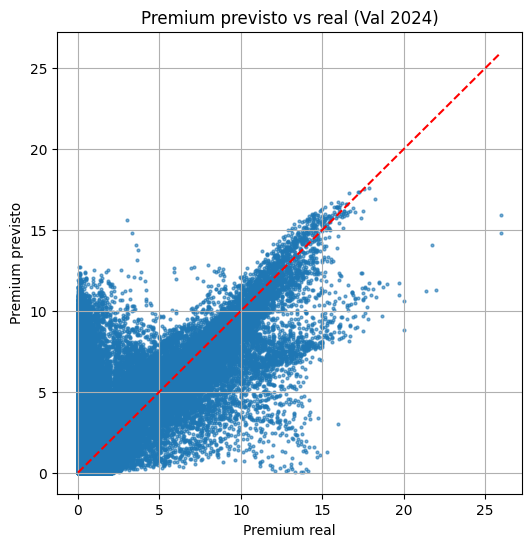

In [10]:
#  Scatter price_pred vs real (validation)
plt.figure(figsize=(6,6))
plt.scatter(y_val.reshape(-1), price_val_pred, s=4, alpha=0.6)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Premium real')
plt.ylabel('Premium previsto')
plt.title('Premium previsto vs real (Val 2024)')
plt.grid(True)
plt.show()


Plots:  residual histogram

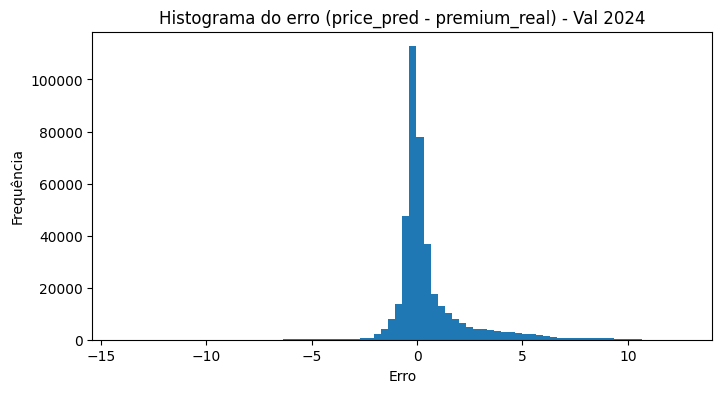

In [11]:
# Residual histogram
resid = (price_val_pred - y_val.reshape(-1))
plt.figure(figsize=(8,4))
plt.hist(resid, bins=80)
plt.title('Histograma do erro (price_pred - premium_real) - Val 2024')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.show()

Plots: sigma_pred vs implied_vol (scatter)

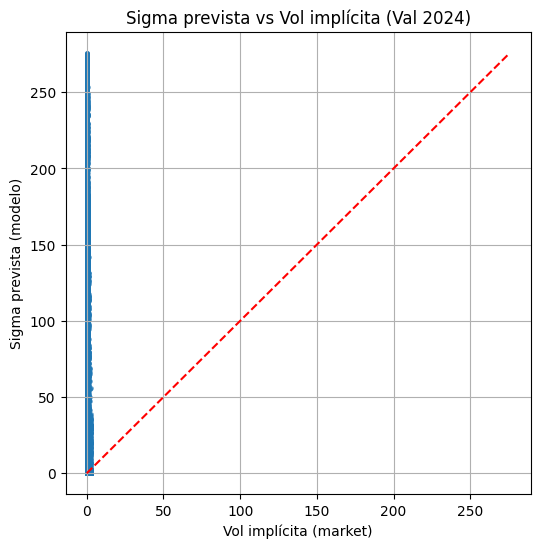

In [12]:
# Volatility comparison
plt.figure(figsize=(6,6))
plt.scatter(iv_val[mask_valid_iv], sigma_val_pred[mask_valid_iv], s=6, alpha=0.6)
plt.plot([0, max(np.nanmax(iv_val), np.nanmax(sigma_val_pred))], [0, max(np.nanmax(iv_val), np.nanmax(sigma_val_pred))], 'r--')
plt.xlabel('Vol implícita (market)')
plt.ylabel('Sigma prevista (modelo)')
plt.title('Sigma prevista vs Vol implícita (Val 2024)')
plt.grid(True)
plt.show()

Plots: estatísticas

In [13]:
# Estatísticas de erro na volatilidade
diff_vol = sigma_val_pred[mask_valid_iv] - iv_val[mask_valid_iv]
print("Vol diff mean:", np.nanmean(diff_vol), "std:", np.nanstd(diff_vol))
print("Vol MSE:", np.nanmean(diff_vol**2))

Vol diff mean: 47.92004618644685 std: 69.62236447168269
Vol MSE: 7143.604461139024


Heatmap de erro por moneyness x tempo (Val)

C:\Users\Rubens Molina\AppData\Local\Temp\ipykernel_28032\2982546239.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_val.pivot_table(index='moneyness_bin', columns='T_bin', values='error_abs', aggfunc='mean')


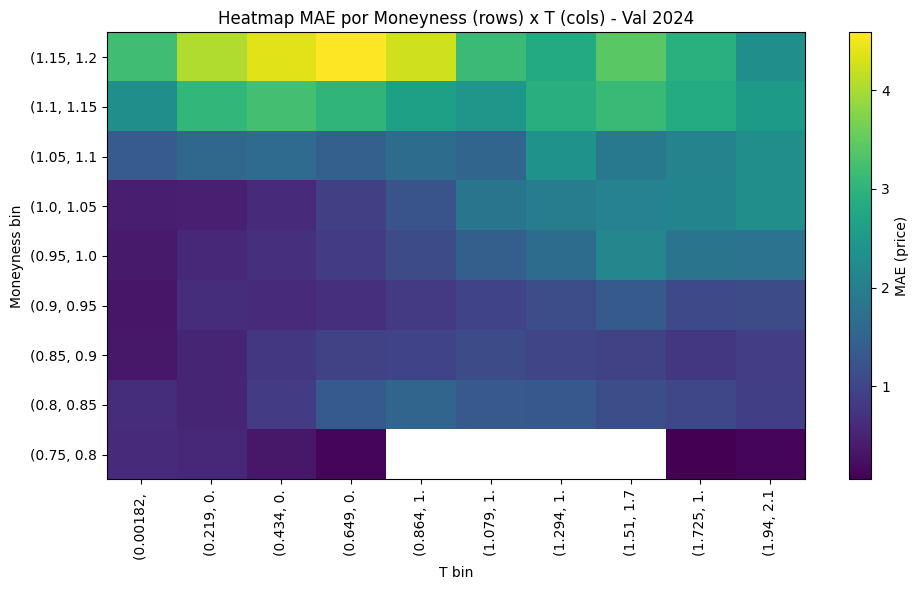

In [14]:
# Heatmap de erro por moneyness x T
df_val['price_pred'] = price_val_pred
df_val['error_abs'] = np.abs(df_val['price_pred'] - df_val['premium'])
# moneyness
df_val['moneyness'] = df_val['spot_price'] / df_val['strike']
# bins
df_val['moneyness_bin'] = pd.cut(df_val['moneyness'], bins=np.linspace(0.5,1.5,21))
df_val['T_bin'] = pd.cut(df_val['time_to_maturity'], bins=10)

pivot = df_val.pivot_table(index='moneyness_bin', columns='T_bin', values='error_abs', aggfunc='mean')
plt.figure(figsize=(10,6))
plt.imshow(pivot.values, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='MAE (price)')
plt.title('Heatmap MAE por Moneyness (rows) x T (cols) - Val 2024')
plt.xlabel('T bin')
plt.ylabel('Moneyness bin')
plt.xticks(ticks=np.arange(pivot.shape[1]), labels=[str(c)[:10] for c in pivot.columns], rotation=90)
plt.yticks(ticks=np.arange(pivot.shape[0]), labels=[str(i)[:10] for i in pivot.index])
plt.tight_layout()
plt.show()


Superfície de preço prevista (amostra)

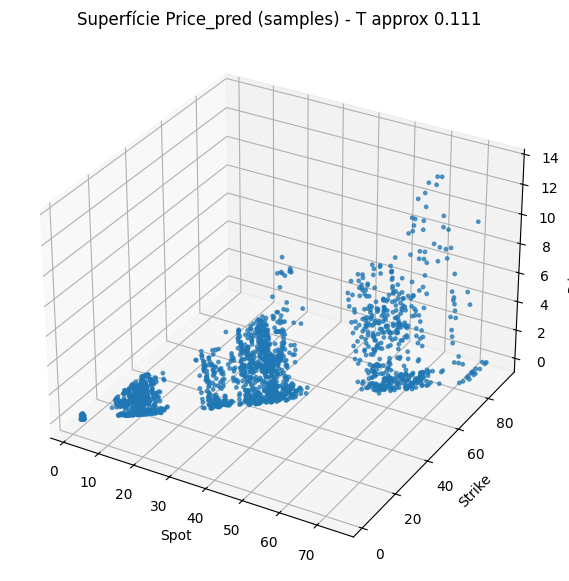

In [15]:
# Superfície price(S,K) para um tempo fixed (amostra)
# Escolha um T index médio e construa superfície
sample_df = df_val.copy()
# filtra por maturidade próxima de median
T_med = sample_df['time_to_maturity'].median()
sample_sub = sample_df[np.abs(sample_df['time_to_maturity'] - T_med) < (0.02 * T_med)]
# Take subset for plotting
plot_df = sample_sub.sample(n=min(2000, len(sample_sub)), random_state=42)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(plot_df['spot_price'], plot_df['strike'], plot_df['price_pred'], s=6, alpha=0.7)
ax.set_xlabel('Spot')
ax.set_ylabel('Strike')
ax.set_zlabel('Price_pred')
ax.set_title(f'Superfície Price_pred (samples) - T approx {T_med:.3f}')
plt.show()


Aggregated metrics & export de resultados para o artigo

In [16]:
# Métricas agregadas e export
metrics_summary = {
    'train_price_mse': metrics_train['mse'],
    'train_price_rmse': metrics_train['rmse'],
    'train_price_mae': metrics_train['mae'],
    'val_price_mse': metrics_val['mse'],
    'val_price_rmse': metrics_val['rmse'],
    'val_price_mae': metrics_val['mae'],
    'vol_val_mse': float(mse_vol)
}
metrics_summary

{'train_price_mse': np.float64(4.453324617549071),
 'train_price_rmse': np.float64(2.1102901737792057),
 'train_price_mae': np.float64(1.0045098363321179),
 'val_price_mse': np.float64(3.2907678307511437),
 'val_price_rmse': np.float64(1.8140473617717767),
 'val_price_mae': np.float64(0.9574584708429847),
 'vol_val_mse': 7143.604461139024}

Salvando os resultados de validação

In [17]:
# Salva CSV com predições e erros (útil para tabelas e análises no artigo)
out_val = df_val.copy()
out_val['price_pred'] = price_val_pred
out_val['sigma_pred'] = sigma_val_pred
out_val['implied_vol'] = iv_val
out_val['error_price'] = out_val['price_pred'] - out_val['premium']
out_val.to_csv(os.path.join(PATH_RESULTS, 'val_predictions.csv'), index=False)
print("Arquivo salvo:", os.path.join(PATH_RESULTS, 'val_predictions.csv'))

Arquivo salvo: d:\UERJ\Programacao_e_Codigos\PINN_Opcoes_BR\resultados\val_predictions.csv


In [ ]:
df_validation = pd.read_csv("resultados\\val_predictions.csv")

### d. Para processar um novo data_history.csv

In [18]:
# Célula 1: Imports adicionais (se já não estiverem no notebook)
import os
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm # Para a barra de progresso

# Importar as funções de física para calcular as perdas
from src.physics import black_scholes_residual, payoff_boundary_condition

# Assegure-se de que o modelo, device, data_stats e X_train, y_train já foram carregados
# (O seu notebook 'avaliacao_treino.ipynb' já faz isso nas primeiras células)
print("Variáveis necessárias (model, device, data_stats, X_train, y_train) devem estar carregadas.")

Variáveis necessárias (model, device, data_stats, X_train, y_train) devem estar carregadas.


In [19]:
# Célula 2: Criar o DataLoader de TREINO
# (O notebook de avaliação foca no 'val', aqui usamos o 'train')

# 1. Criar o TensorDataset e DataLoader com os dados de TREINO
train_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
train_loader = DataLoader(
    train_dataset, 
    batch_size=TRAINING_CONFIG['batch_size'], 
    shuffle=False # Não precisa embaralhar para avaliação
)

# 2. Definir o tamanho do batch para os pontos de colocação (física)
phy_batch_size = TRAINING_CONFIG['phy_batch_size']

print(f"DataLoader de treino pronto com {len(train_dataset)} amostras.")

DataLoader de treino pronto com 894278 amostras.


In [20]:
# Célula 3: Loop de Avaliação (MODIFICADO para salvar CADA iteração)
# Este é o núcleo da lógica. Vamos calcular todas as perdas, sem otimizador.

# Coloca o modelo em modo de avaliação (desliga dropout, etc.)
model.eval()

# <--- MODIFICADO ---
# Lista para armazenar um dicionário para CADA iteração (batch)
history_rows = []

# Criamos uma barra de progresso e usamos enumerate para ter um ID de iteração
pbar = tqdm(enumerate(train_loader), desc="Avaliando perdas por iteração", total=len(train_loader))

# ATENÇÃO: Mesmo em 'eval', precisamos dos gradientes para L_pde e L_reg.
# Por isso, usamos torch.enable_grad() e .requires_grad_(True)
# mas NÃO chamamos optimizer.step()

with torch.enable_grad(): # Habilita o cálculo de gradientes
    for i, batch_data in pbar:
        
        inputs, premiums_real = batch_data
        inputs, premiums_real = inputs.to(device), premiums_real.to(device)
        
        # É CRÍTICO setar isso, pois precisamos dos gradientes para a PDE e REG
        inputs.requires_grad_(True)

        # --- 1. Perda de Dados (L_data) ---
        # (Calculada sobre o batch de dados reais)
        model_output = model(inputs)
        price_pred = model_output['price']
        loss_data = torch.nn.functional.mse_loss(price_pred, premiums_real)

        # --- 2. Perda de Contorno (L_boundary) ---
        # (Copiado do trainer.py)
        n_boundary = max(1, inputs.size(0) // 4)
        s_boundary = torch.rand(n_boundary, 1, device=device)
        k_boundary = torch.rand(n_boundary, 1, device=device)
        t_boundary = torch.zeros(n_boundary, 1, device=device)  # t=0 (vencimento)
        r_boundary = torch.rand(n_boundary, 1, device=device)
        p_boundary = torch.zeros(n_boundary, 1, device=device)  # premium dummy
        boundary_inputs = torch.cat([s_boundary, k_boundary, t_boundary, r_boundary, p_boundary], dim=1)
        
        S_b = s_boundary * (data_stats['S_max'] - data_stats['S_min']) + data_stats['S_min']
        K_b = k_boundary * (data_stats['K_max'] - data_stats['K_min']) + data_stats['K_min']
        payoff_real = payoff_boundary_condition(S_b, K_b)
        
        price_pred_boundary = model(boundary_inputs)['price']
        loss_boundary = torch.nn.functional.mse_loss(price_pred_boundary, payoff_real)

        # --- 3. Perda de PDE (L_pde) e Regularização (L_reg) ---
        # (Calculada sobre pontos de colocação aleatórios)
        
        # Gerar pontos de colocação uniformes (simples)
        input_price_size = model.config['input_size'] - 1
        points_price = torch.rand(phy_batch_size, input_price_size, device=device)
        zeros_col = torch.zeros(phy_batch_size, 1, device=device)
        collocation_points = torch.cat([points_price, zeros_col], dim=1)
        collocation_points.requires_grad_(True) # CRÍTICO

        # Passada do modelo nos pontos de física
        output_phy = model(collocation_points)
        sigma_phy = output_phy['sigma']

        # Calcular L_reg (copiado do trainer)
        grad_sigma = torch.autograd.grad(
            sigma_phy, collocation_points,
            grad_outputs=torch.ones_like(sigma_phy),
            create_graph=True,
            retain_graph=True # Precisa reter o grafo para o 'pde_res'
        )[0]
        
        grad_sigma_S = grad_sigma[:, 0]
        grad_sigma_K = grad_sigma[:, 1]
        grad_sigma_T = grad_sigma[:, 2]
        
        loss_reg_sigma = torch.mean(torch.square(grad_sigma_S)) + \
                         torch.mean(torch.square(grad_sigma_K)) + \
                         torch.mean(torch.square(grad_sigma_T))
        
        # Calcular L_pde (copiado do trainer)
        # (output_phy já foi calculado, e o grafo foi retido)
        pde_res = black_scholes_residual(output_phy, collocation_points, data_stats)
        loss_pde = torch.nn.functional.mse_loss(pde_res, torch.zeros_like(pde_res))

        # --- 4. Calcular Perda Total e Armazenar Linha ---
        loss_total = loss_data + loss_pde + loss_reg_sigma + loss_boundary
        
        # <--- MODIFICADO ---
        # Cria um dicionário para esta linha (iteração)
        row = {
            'iteration': i,
            'train_loss_data': loss_data.item(),
            'train_loss_pde': loss_pde.item(),
            'train_loss_reg': loss_reg_sigma.item(),
            'train_loss_boundary': loss_boundary.item(),
            'train_loss_total': loss_total.item()
        }
        # Adiciona o dicionário à lista
        history_rows.append(row)
        
        pbar.set_postfix_str(f"Iter {i}, L_total: {loss_total.item():.3e}")

pbar.close()
print("Avaliação de perdas por iteração concluída.")

Avaliando perdas por iteração:   5%|▍         | 5/110 [00:30<10:48,  6.17s/it, Iter 4, L_total: 2.019e+01]


KeyboardInterrupt: 

In [ ]:
# Célula 4: Criar DataFrame e Salvar o Novo CSV (por Iteração)

# <--- MODIFICADO ---
# 1. Criar o DataFrame a partir da lista de dicionários
df_history = pd.DataFrame(history_rows)

# 2. Salvar no local desejado
output_dir = os.path.join('dados', 'arquivos_diversos')
os.makedirs(output_dir, exist_ok=True)

# Mudei o nome para refletir o conteúdo (por iteração)
output_path = os.path.join(output_dir, 'training_history_per_iteration.csv')

df_history.to_csv(output_path, index=False)

print(f"\nNovo 'training_history_per_iteration.csv' (com {len(df_history)} iterações) salvo com sucesso em: {output_path}")

# Mostra as primeiras linhas para verificação
print("\n--- Amostra do DataFrame (primeiras 5 linhas) ---")
print(df_history.head())


Novo 'training_history_per_iteration.csv' (com 110 iterações) salvo com sucesso em: dados\arquivos_diversos\training_history_per_iteration.csv

--- Amostra do DataFrame (primeiras 5 linhas) ---
   iteration  train_loss_data  train_loss_pde  train_loss_reg  \
0          0         8.994117        0.023429       59.886024   
1          1         1.645983        0.101554       63.755310   
2          2         0.326178        0.001599       22.044220   
3          3         0.430132        0.001988       27.820700   
4          4         0.412180        0.179211       67.838623   

   train_loss_boundary  train_loss_total  
0             0.007869         68.911438  
1             0.004295         65.507141  
2             0.003632         22.375629  
3             0.001823         28.254644  
4             0.002779         68.432793  


In [ ]:
df_history


,iteration,train_loss_data,train_loss_pde,train_loss_reg,train_loss_boundary,train_loss_total
0,0,8.994117,0.023429,59.886024,0.007869,68.911438
1,1,1.645983,0.101554,63.755310,0.004295,65.507141
2,2,0.326178,0.001599,22.044220,0.003632,22.375629
3,3,0.430132,0.001988,27.820700,0.001823,28.254644
4,4,0.412180,0.179211,67.838623,0.002779,68.432793
...,...,...,...,...,...,...
105,105,8.887409,0.000986,58.684002,0.006021,67.578415
106,106,9.537710,0.002007,52.695114,0.003539,62.238373
107,107,9.916238,0.013617,26.740963,0.004783,36.675602
108,108,12.839834,0.021948,32.247849,0.004240,45.113873


INFOS

In [ ]:
# Célula 1: Imports adicionais (se já não estiverem no notebook)
import os
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm # Para a barra de progresso
import numpy as np # Adicionado para np.mean (embora usaremos torch.mean)

# Importar as funções de física para calcular as perdas
from src.physics import black_scholes_residual, payoff_boundary_condition

# Assegure-se de que o modelo, device, data_stats e X_train, y_train já foram carregados
# (O seu notebook 'avaliacao_treino.ipynb' já faz isso nas primeiras células)
print("Variáveis necessárias (model, device, data_stats, X_train, y_train) devem estar carregadas.")

Variáveis necessárias (model, device, data_stats, X_train, y_train) devem estar carregadas.


In [ ]:
# Célula 2: Criar o DataLoader de TREINO
# (O notebook de avaliação foca no 'val', aqui usamos o 'train')

# 1. Criar o TensorDataset e DataLoader com os dados de TREINO
train_dataset = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
train_loader = DataLoader(
    train_dataset, 
    batch_size=TRAINING_CONFIG['batch_size'], 
    shuffle=False # Não precisa embaralhar para avaliação
)

# 2. Definir o tamanho do batch para os pontos de colocação (física)
phy_batch_size = TRAINING_CONFIG['phy_batch_size']

print(f"DataLoader de treino pronto com {len(train_dataset)} amostras.")

DataLoader de treino pronto com 894278 amostras.


In [ ]:
# Célula 3: Loop de Avaliação (MODIFICADO para salvar predições e perdas por iteração)
# Este é o núcleo da lógica. Vamos calcular todas as perdas, sem otimizador.

# Coloca o modelo em modo de avaliação (desliga dropout, etc.)
model.eval()

# <--- MODIFICADO ---
# Listas para armazenar as métricas de CADA iteração (batch)
history_rows = []

# Criamos uma barra de progresso e usamos enumerate
pbar = tqdm(enumerate(train_loader), desc="Avaliando perdas e predições por iteração", total=len(train_loader))

# ATENÇÃO: Mesmo em 'eval', precisamos dos gradientes para L_pde e L_reg.
# Por isso, usamos torch.enable_grad() e .requires_grad_(True)
# mas NÃO chamamos optimizer.step()

with torch.enable_grad(): # Habilita o cálculo de gradientes
    for i, batch_data in pbar:
        
        inputs, premiums_real = batch_data
        inputs, premiums_real = inputs.to(device), premiums_real.to(device)
        
        # É CRÍTICO setar isso, pois precisamos dos gradientes para a PDE e REG
        inputs.requires_grad_(True)

        # --- 1. Perda de Dados (L_data) e PREDIÇÕES ---
        # (Calculada sobre o batch de dados reais)
        model_output = model(inputs)
        price_pred = model_output['price']
        sigma_pred = model_output['sigma'] # <--- NOVO: Captura o sigma previsto
        
        loss_data = torch.nn.functional.mse_loss(price_pred, premiums_real)

        # --- 2. Perda de Contorno (L_boundary) ---
        n_boundary = max(1, inputs.size(0) // 4)
        s_boundary = torch.rand(n_boundary, 1, device=device)
        k_boundary = torch.rand(n_boundary, 1, device=device)
        t_boundary = torch.zeros(n_boundary, 1, device=device)  # t=0 (vencimento)
        r_boundary = torch.rand(n_boundary, 1, device=device)
        p_boundary = torch.zeros(n_boundary, 1, device=device)  # premium dummy
        boundary_inputs = torch.cat([s_boundary, k_boundary, t_boundary, r_boundary, p_boundary], dim=1)
        
        S_b = s_boundary * (data_stats['S_max'] - data_stats['S_min']) + data_stats['S_min']
        K_b = k_boundary * (data_stats['K_max'] - data_stats['K_min']) + data_stats['K_min']
        payoff_real = payoff_boundary_condition(S_b, K_b)
        
        price_pred_boundary = model(boundary_inputs)['price']
        loss_boundary = torch.nn.functional.mse_loss(price_pred_boundary, payoff_real)

        # --- 3. Perda de PDE (L_pde) e Regularização (L_reg) ---
        input_price_size = model.config['input_size'] - 1
        points_price = torch.rand(phy_batch_size, input_price_size, device=device)
        zeros_col = torch.zeros(phy_batch_size, 1, device=device)
        collocation_points = torch.cat([points_price, zeros_col], dim=1)
        collocation_points.requires_grad_(True) # CRÍTICO

        output_phy = model(collocation_points)
        sigma_phy = output_phy['sigma']

        grad_sigma = torch.autograd.grad(
            sigma_phy, collocation_points,
            grad_outputs=torch.ones_like(sigma_phy),
            create_graph=True,
            retain_graph=True 
        )[0]
        
        grad_sigma_S = grad_sigma[:, 0]
        grad_sigma_K = grad_sigma[:, 1]
        grad_sigma_T = grad_sigma[:, 2]
        
        loss_reg_sigma = torch.mean(torch.square(grad_sigma_S)) + \
                         torch.mean(torch.square(grad_sigma_K)) + \
                         torch.mean(torch.square(grad_sigma_T))
        
        pde_res = black_scholes_residual(output_phy, collocation_points, data_stats)
        loss_pde = torch.nn.functional.mse_loss(pde_res, torch.zeros_like(pde_res))

        # --- 4. Calcular Total, Médias e Armazenar Linha ---
        loss_total = loss_data + loss_pde + loss_reg_sigma + loss_boundary
        
        # <--- NOVO: Calcula médias das predições e real para este batch ---
        avg_premium_real = premiums_real.mean().item()
        avg_price_pred = price_pred.mean().item()
        avg_sigma_pred = sigma_pred.mean().item()

        # <--- MODIFICADO ---
        # Cria um dicionário para esta linha (iteração)
        row = {
            'iteration': i,
            'train_loss_data': loss_data.item(),
            'train_loss_pde': loss_pde.item(),
            'train_loss_reg': loss_reg_sigma.item(),
            'train_loss_boundary': loss_boundary.item(),
            'train_loss_total': loss_total.item(),
            'avg_premium_real': avg_premium_real, # <--- NOVO
            'avg_price_pred': avg_price_pred,       # <--- NOVO
            'avg_sigma_pred': avg_sigma_pred        # <--- NOVO
        }
        # Adiciona o dicionário à lista
        history_rows.append(row)
        
        pbar.set_postfix_str(f"Iter {i}, L_total: {loss_total.item():.3e}, Avg_Price: {avg_price_pred:.2f}, Avg_Sigma: {avg_sigma_pred:.3f}")

pbar.close()
print("Avaliação de perdas e predições por iteração concluída.")

Avaliando perdas e predições por iteração:  38%|███▊      | 42/110 [02:50<04:35,  4.05s/it, Iter 41, L_total: 3.377e+01, Avg_Price: 1.56, Avg_Sigma: 70.031]


KeyboardInterrupt: 

In [ ]:
# Célula 4: Criar DataFrame e Salvar o Novo CSV (por Iteração)

# <--- MODIFICADO ---
# 1. Criar o DataFrame a partir da lista de dicionários
df_history = pd.DataFrame(history_rows)

# 2. Salvar no local desejado
output_dir = os.path.join('dados', 'arquivos_diversos')
os.makedirs(output_dir, exist_ok=True)

# Mudei o nome para refletir o conteúdo (por iteração)
output_path = os.path.join(output_dir, 'train_predictions_and_losses_per_iteration.csv')

df_history.to_csv(output_path, index=False)

print(f"\nNovo 'train_predictions_and_losses_per_iteration.csv' (com {len(df_history)} iterações) salvo com sucesso em: {output_path}")

# Mostra as primeiras linhas para verificação
print("\n--- Amostra do DataFrame (primeiras 5 linhas) ---")
print(df_history.head())